In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("fraud_oracle_raw.csv")

In [4]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [6]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [7]:
#start checking the columns data 
df["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [9]:
round(df["FraudFound_P"].mean() * 100, 2) #finding the percentage that this data has for Fraud Dectect --> 6%

np.float64(5.99)

In [8]:
df["AddressChange_Claim"].value_counts()

AddressChange_Claim
no change         14324
4 to 8 years        631
2 to 3 years        291
1 year              170
under 6 months        4
Name: count, dtype: int64

In [10]:
df.nunique().sort_values()

WitnessPresent              2
AgentType                   2
FraudFound_P                2
AccidentArea                2
PoliceReportFiled           2
Fault                       2
Sex                         2
Year                        3
BasePolicy                  3
VehicleCategory             3
PastNumberOfClaims          4
Days_Policy_Claim           4
DriverRating                4
Deductible                  4
MaritalStatus               4
NumberOfSuppliments         4
NumberOfCars                5
WeekOfMonthClaimed          5
Days_Policy_Accident        5
AddressChange_Claim         5
WeekOfMonth                 5
VehiclePrice                6
DayOfWeek                   7
DayOfWeekClaimed            8
AgeOfVehicle                8
PolicyType                  9
AgeOfPolicyHolder           9
Month                      12
MonthClaimed               13
RepNumber                  16
Make                       19
Age                        66
PolicyNumber            15420
dtype: int

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WeekOfMonth,15420.0,2.788586,1.287585,1.0,2.00,3.0,4.00,5.0
WeekOfMonthClaimed,15420.0,2.693969,1.259115,1.0,2.00,3.0,4.00,5.0
Age,15420.0,39.855707,13.492377,0.0,31.00,38.0,48.00,80.0
FraudFound_P,15420.0,0.059857,0.237230,0.0,0.00,0.0,0.00,1.0
PolicyNumber,15420.0,7710.500000,4451.514911,1.0,3855.75,7710.5,11565.25,15420.0
RepNumber,15420.0,8.483268,4.599948,1.0,5.00,8.0,12.00,16.0
Deductible,15420.0,407.704280,43.950998,300.0,400.00,400.0,400.00,700.0
DriverRating,15420.0,2.487808,1.119453,1.0,1.00,2.0,3.00,4.0
Year,15420.0,1994.866472,0.803313,1994.0,1994.00,1995.0,1996.00,1996.0


In [12]:
print("Age == 0", (df["Age"]==0).sum()) #check how many 0 input for this columns which can transfer to NA 

Age == 0 320


In [13]:
df_copy = df.copy()
label = df_copy["FraudFound_P"]

In [15]:
df_copy = df_copy[df_copy['DayOfWeekClaimed'] != '0'].reset_index(drop=True)
#reseting the index and dropping the row keeping the index 

In [16]:
df_copy['age_was_missing'] = df_copy['Age'] == 0
df_copy.loc[df_copy['Age']==0, 'Age'] = 16
# minimum driving age

# check 
print((df_copy['Age']==0).sum())          # should be 0 now
print(df_copy['age_was_missing'].sum())   # should be 320
print(df_copy['Age'].describe())          # min should now be 16, not 0

# make sure df never changed
print((df['Age'] == 0).sum())

0
319
count    15419.000000
mean        40.189312
std         12.678745
min         16.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64
320


In [17]:
# final checks before feature selection
print(df_copy.shape)
print(df_copy.isnull().sum().sum())
print(df_copy.duplicated().sum())
print((df_copy['Age']==0).sum())
print(df_copy['Age'].describe())
print(df_copy['age_was_missing'].sum())

(15419, 34)
0
0
0
count    15419.000000
mean        40.189312
std         12.678745
min         16.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64
319


In [18]:
#Rename the target and drop the ID column
df_copy = df_copy.rename(columns={"FraudFound_P": "IsFraud"})
df_copy = df_copy.drop(columns="PolicyNumber")

do we have to save the file to the original csv which change the file data after cleaning?

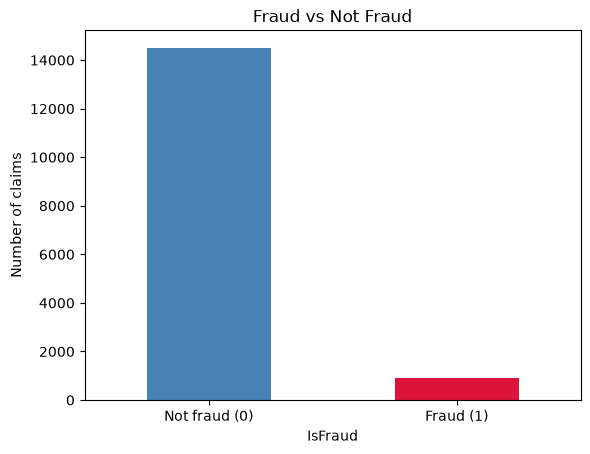

In [19]:
df_copy["IsFraud"].value_counts().plot(kind="bar", title="Fraud vs Not Fraud", color=["steelblue", "crimson"])
plt.xticks([0, 1], ["Not fraud (0)", "Fraud (1)"], rotation=0)
plt.ylabel("Number of claims")
plt.show()

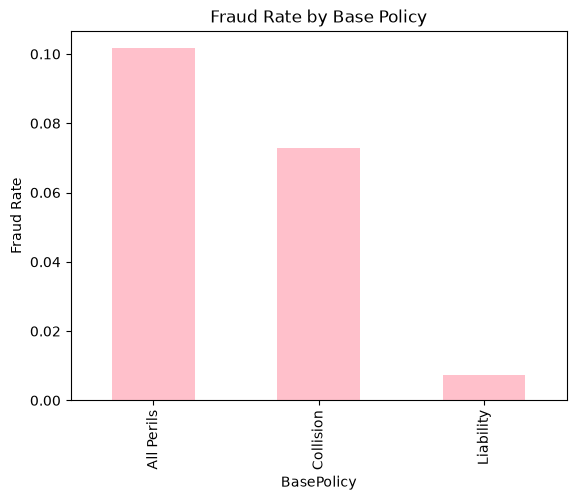

In [20]:
fraud_by_policy = df_copy.groupby("BasePolicy")["IsFraud"].mean().sort_values(ascending=False)
fraud_by_policy.plot(kind="bar", title="Fraud Rate by Base Policy", color="pink")
plt.ylabel("Fraud Rate")
plt.show()

We all can tell All Perillis and Collision has higher Fraud Rate than Liability, so maybe that where the next columns we should look into or target while training the model 

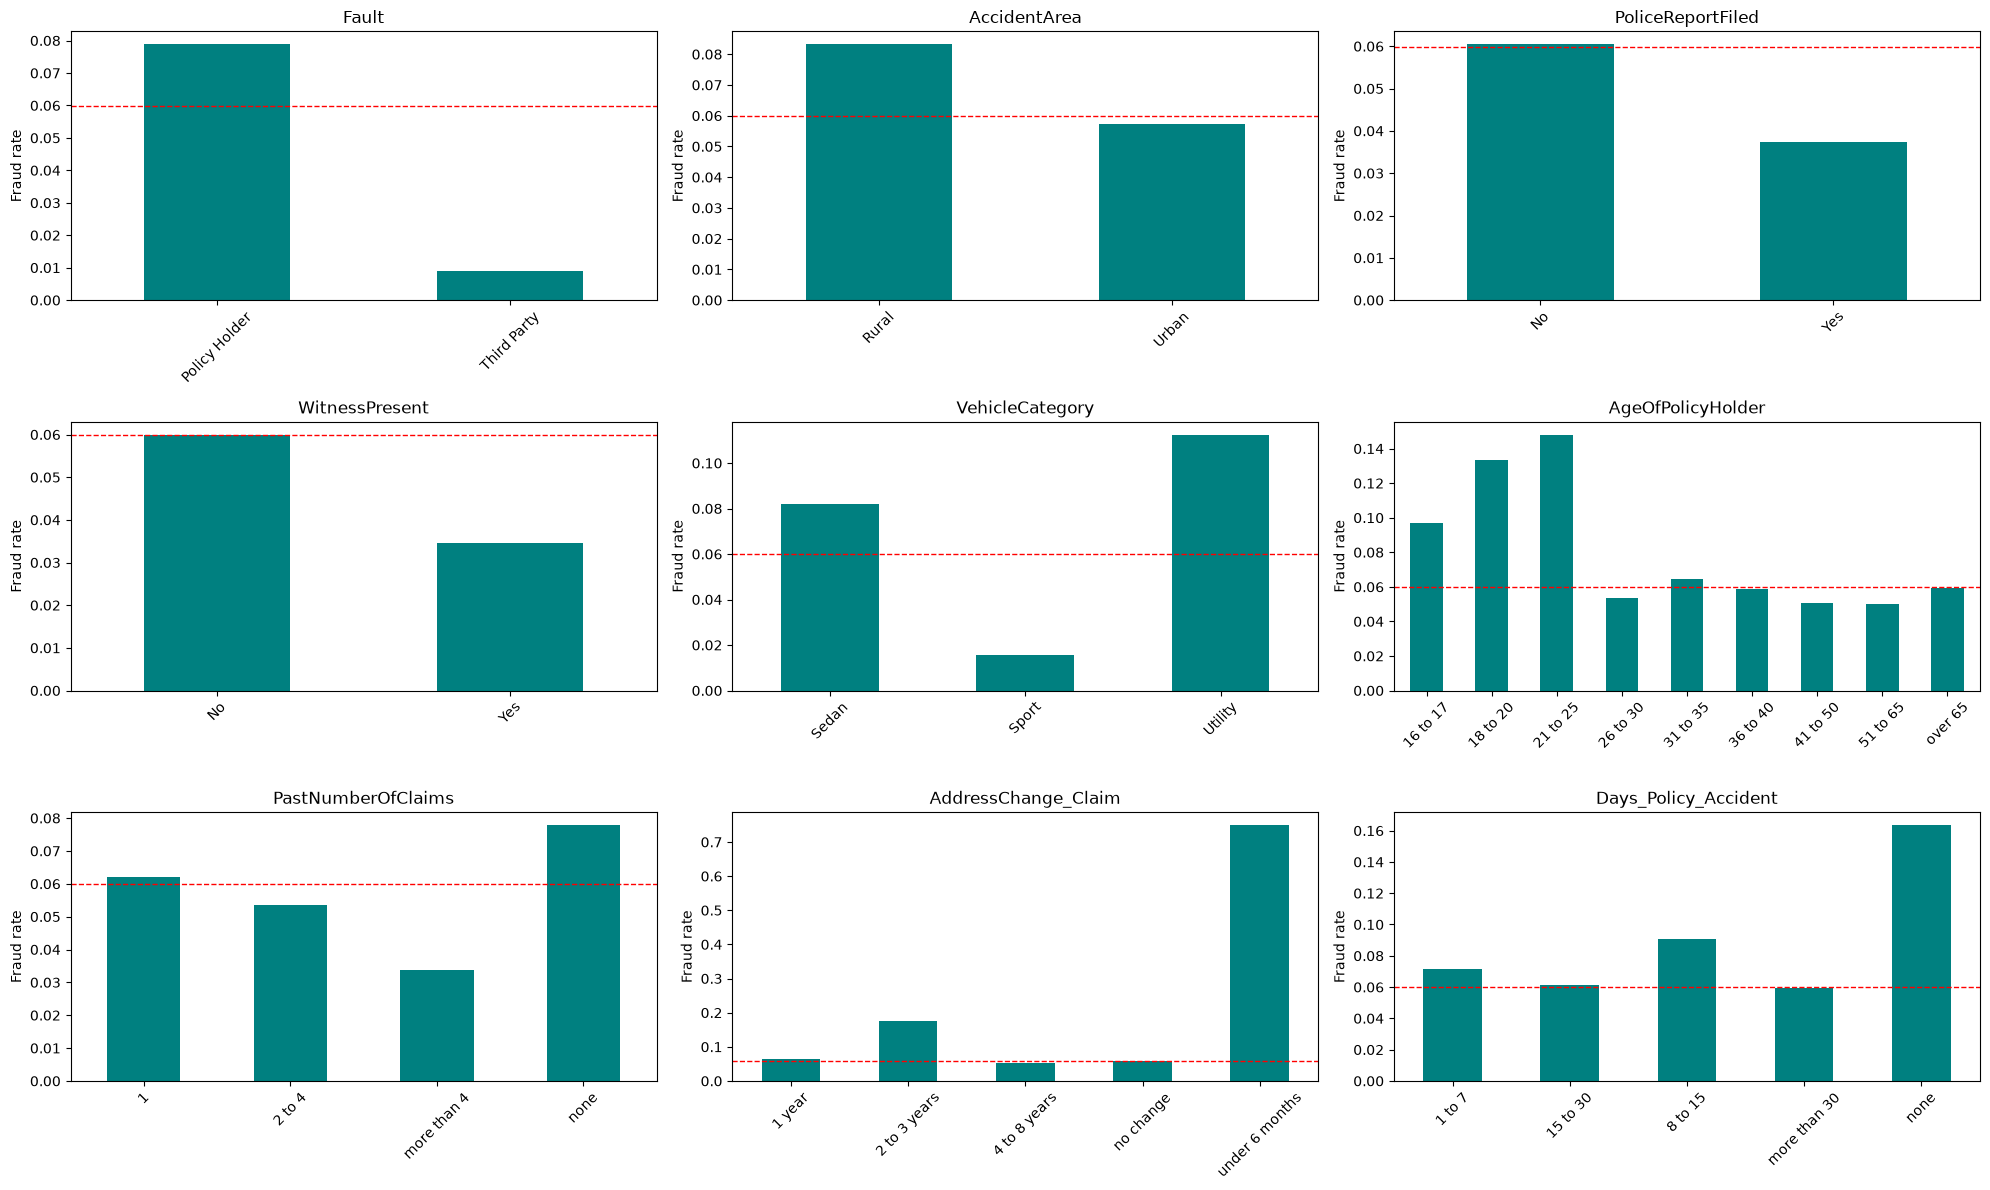

In [24]:
cols = ["Fault", "AccidentArea", "PoliceReportFiled", "WitnessPresent",
         "VehicleCategory", "AgeOfPolicyHolder", "PastNumberOfClaims",
        "AddressChange_Claim", "Days_Policy_Accident", "AgeOfVehicle", "Deductible"]

overall = df_copy["IsFraud"].mean()
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
for ax, col in zip(axes.flat, cols):
    rate = df_copy.groupby(col, observed=True)["IsFraud"].mean()
    rate.plot(kind="bar", ax=ax, color="teal")
    ax.axhline(overall, color="red", linestyle="--", linewidth=1)   # red line = overall fraud rate
    ax.set_title(col); ax.set_xlabel(""); ax.set_ylabel("Fraud rate")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The common Fraud Rate for among all these categories is 0.06% just like how the data detect. Even if there are more fraud, we are currently not sure. But we do have an overview of which graph or columns matter when discuss with the Challenger Advisor on which columns we want to focus on. Another noticed is there are less police report about the fraud rate than normal even though they are the first one at the accident scene?

In [25]:
fault_rate = df_copy.groupby("Fault")["IsFraud"].mean()
print(fault_rate.round(3))

Fault
Policy Holder    0.079
Third Party      0.009
Name: IsFraud, dtype: float64


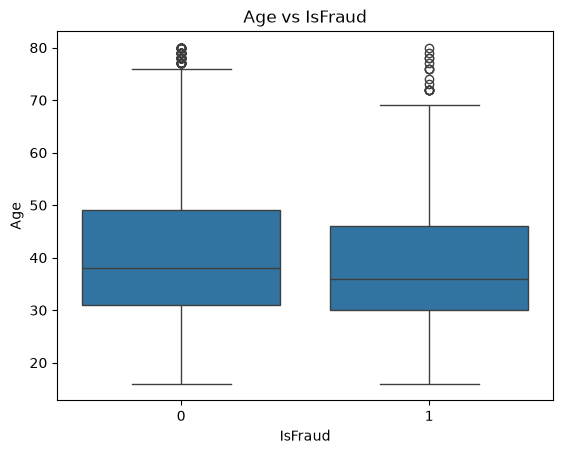

In [27]:
sns.boxplot(data=df_copy, x="IsFraud", y="Age")
plt.title("Age vs IsFraud")
plt.show()

People in the fraudulent group appear slightly younger on average by the median, but this plot alone does not show that age is a strong way to predict fraud. So we should find another categories in this case? what is everyone suggestion?

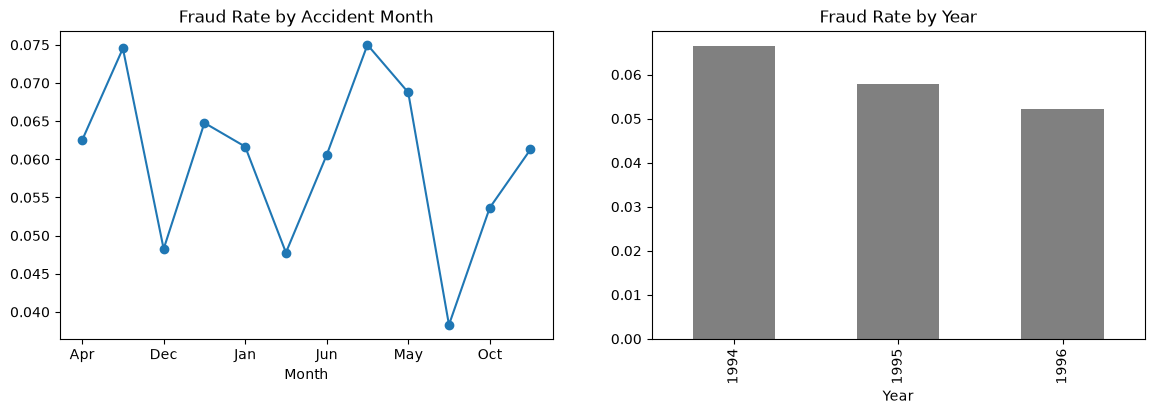

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_copy.groupby("Month", observed=True)["IsFraud"].mean().plot(ax=axes[0], marker="o", title="Fraud Rate by Accident Month")
df_copy.groupby("Year")["IsFraud"].mean().plot(kind="bar", ax=axes[1], title="Fraud Rate by Year", color="gray")
plt.show()

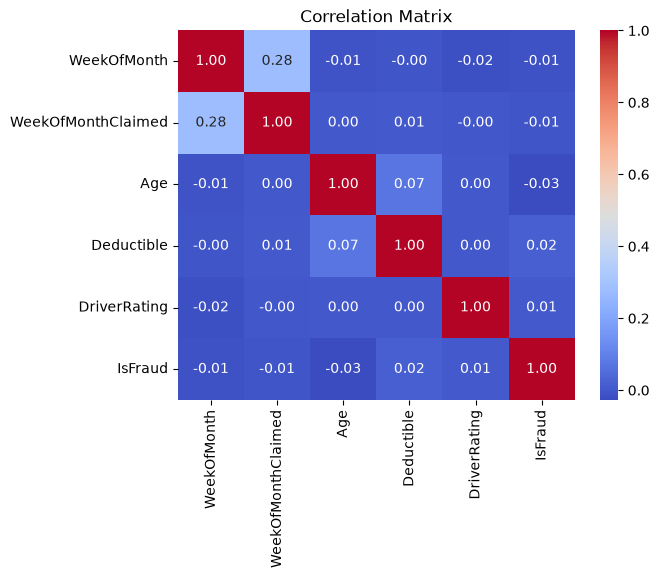

In [29]:
num_cols = ["WeekOfMonth", "WeekOfMonthClaimed", "Age", "Deductible", "DriverRating", "IsFraud"]
corr = df_copy[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Note: value near 0 means little linear relationship; values closer to 1 or −1 mean a stronger relationship. But I am not sure what way to present the correlation. 

In [ ]:
#feature engineering
